# EDA 001.02 — Scaling and Normalization

**Kaggle Data Cleaning Course — Lesson 2**

Numeric features often live on very different scales. This notebook covers:

1. **Why** scaling matters (distance-based models, gradient descent)
2. **Min-Max Scaling** — rescale to [0, 1]
3. **Standardization (Z-score)** — rescale to mean=0, std=1
4. **Robust Scaling** — uses median and IQR (outlier-resistant)
5. **Log Transformation** — for highly skewed data
6. Visual comparison of all methods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1 — Load the Dataset

In [2]:
df = pd.read_csv("data/eda_001_02_house_prices.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (300, 9)


,house_id,area_sqft,bedrooms,age_years,distance_to_center_km,price_usd,crime_rate,school_rating,tax_rate_pct
0,1,4500,4,48,13.45,420151.0,0.0471,2.9,0.84
1,2,2443,1,22,2.42,113373.0,0.1872,2.1,3.25
2,3,3861,4,22,10.94,182951.0,0.0552,7.3,2.83
3,4,3480,5,44,6.89,134411.0,0.2967,2.0,2.97
4,5,506,4,4,13.58,218817.0,0.1209,10.0,3.21


In [3]:
df.describe().round(2)

,house_id,area_sqft,bedrooms,age_years,distance_to_center_km,price_usd,crime_rate,school_rating,tax_rate_pct
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,2778.54,3.05,23.27,10.04,194013.51,0.24,5.46,1.95
std,86.75,1245.19,1.40,14.61,8.72,101806.16,0.14,2.65,0.88
min,1.00,506.00,1.00,0.00,0.08,43766.00,0.01,1.00,0.50
25%,75.75,1734.75,2.00,11.00,4.03,120197.75,0.12,3.20,1.18
50%,150.50,2738.00,3.00,22.00,7.36,173150.00,0.23,5.30,1.92
75%,225.25,3902.00,4.00,35.00,14.28,244115.25,0.36,8.00,2.69
max,300.00,4994.00,5.00,49.00,55.89,586111.00,0.50,10.00,3.48


## 2 — Why Scaling Matters

Look at how wildly different the ranges are across features:

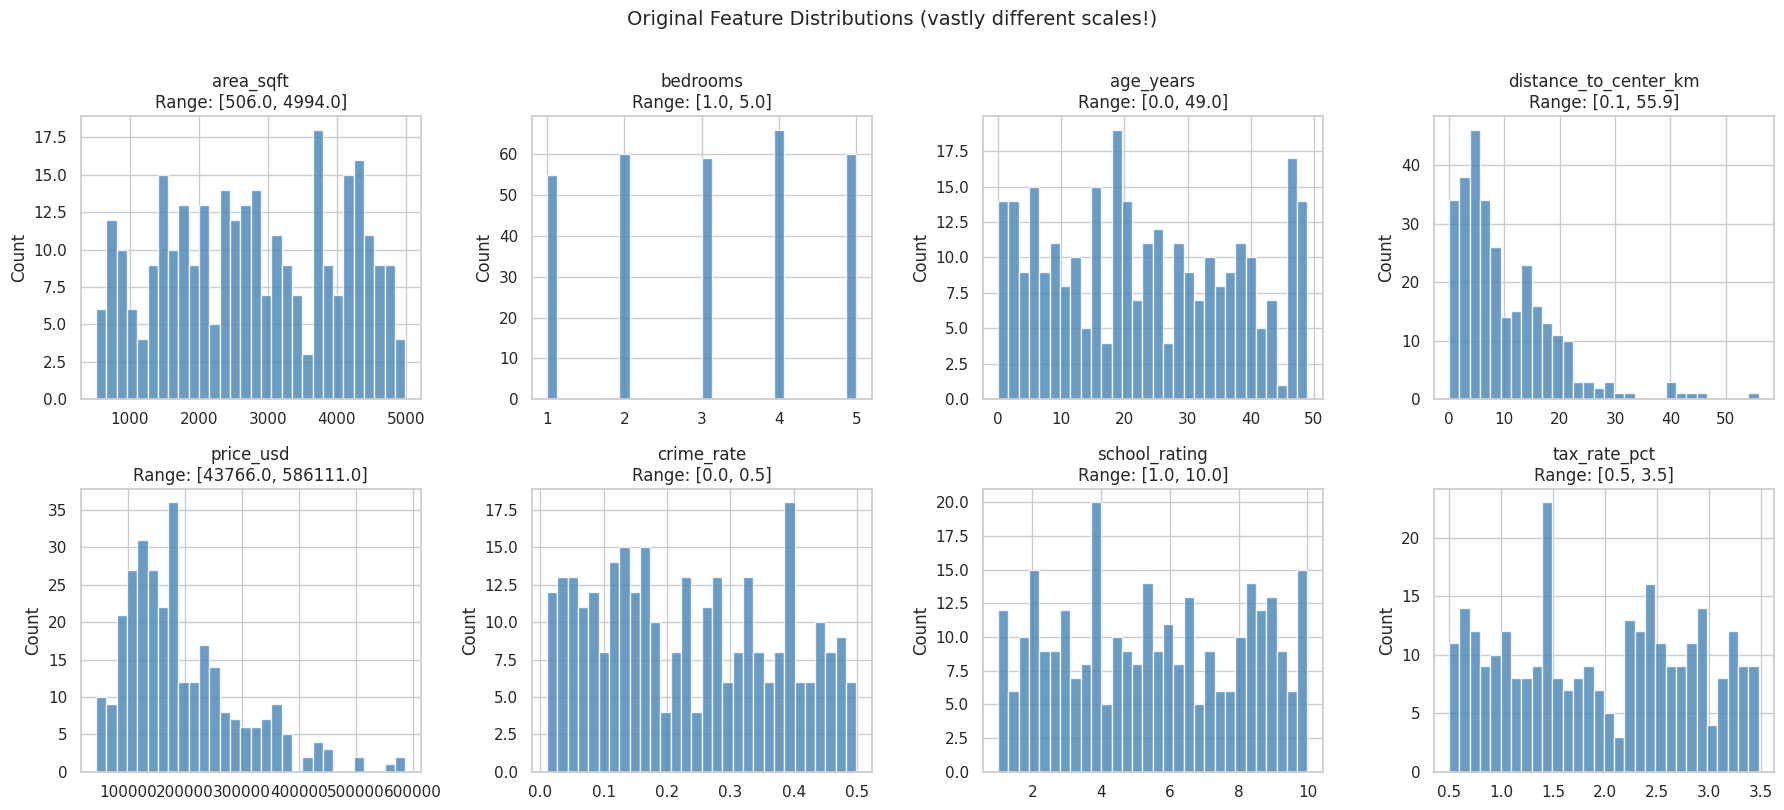

In [4]:
feature_cols = ["area_sqft", "bedrooms", "age_years", "distance_to_center_km",
                "price_usd", "crime_rate", "school_rating", "tax_rate_pct"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    ax.set_title(f"{col}\nRange: [{df[col].min():.1f}, {df[col].max():.1f}]")
    ax.set_ylabel("Count")

plt.suptitle("Original Feature Distributions (vastly different scales!)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3 — Min-Max Scaling

Rescales each feature to the range $[0, 1]$:

$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

**When to use:** When you need bounded values (e.g., neural networks with sigmoid output).

In [5]:
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df[feature_cols]),
    columns=feature_cols
)

print("Min-Max Scaled — all features now in [0, 1]:")
df_minmax.describe().round(3)

Min-Max Scaled — all features now in [0, 1]:


,area_sqft,bedrooms,age_years,distance_to_center_km,price_usd,crime_rate,school_rating,tax_rate_pct
count,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000
mean,0.506,0.513,0.475,0.178,0.277,0.460,0.495,0.486
std,0.277,0.350,0.298,0.156,0.188,0.290,0.295,0.294
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.274,0.250,0.224,0.071,0.141,0.216,0.244,0.230
50%,0.497,0.500,0.449,0.131,0.239,0.440,0.478,0.478
75%,0.757,0.750,0.714,0.254,0.369,0.712,0.778,0.735
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


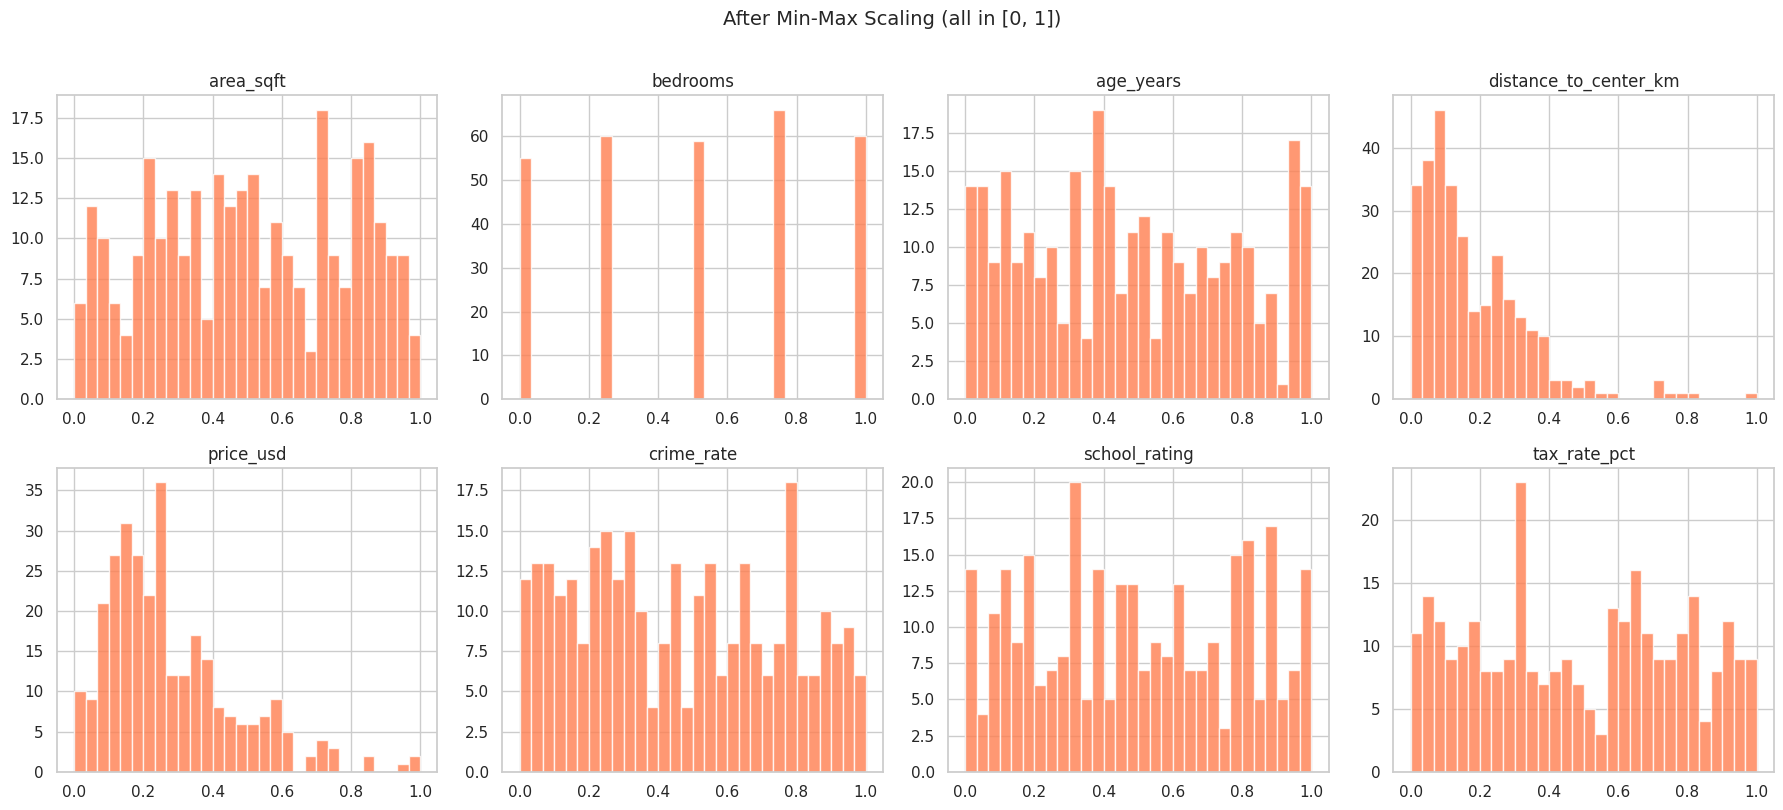

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(df_minmax[col], bins=30, color="coral", edgecolor="white", alpha=0.8)
    ax.set_title(f"{col}")
    ax.set_xlim(-0.05, 1.05)

plt.suptitle("After Min-Max Scaling (all in [0, 1])", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 — Standardization (Z-Score Scaling)

Rescales to mean = 0, standard deviation = 1:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

**When to use:** Most general-purpose choice; works well with linear models, SVMs, PCA.

In [7]:
scaler_std = StandardScaler()
df_standard = pd.DataFrame(
    scaler_std.fit_transform(df[feature_cols]),
    columns=feature_cols
)

print("Standardized — mean ≈ 0, std ≈ 1:")
df_standard.describe().round(3)

Standardized — mean ≈ 0, std ≈ 1:


,area_sqft,bedrooms,age_years,distance_to_center_km,price_usd,crime_rate,school_rating,tax_rate_pct
count,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000
mean,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000,-0.000
std,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002
min,-1.828,-1.470,-1.596,-1.144,-1.478,-1.589,-1.682,-1.656
25%,-0.840,-0.754,-0.841,-0.690,-0.726,-0.842,-0.852,-0.872
50%,-0.033,-0.038,-0.087,-0.307,-0.205,-0.070,-0.059,-0.026
75%,0.904,0.678,0.805,0.486,0.493,0.872,0.960,0.849
max,1.782,1.394,1.765,5.264,3.858,1.866,1.715,1.752


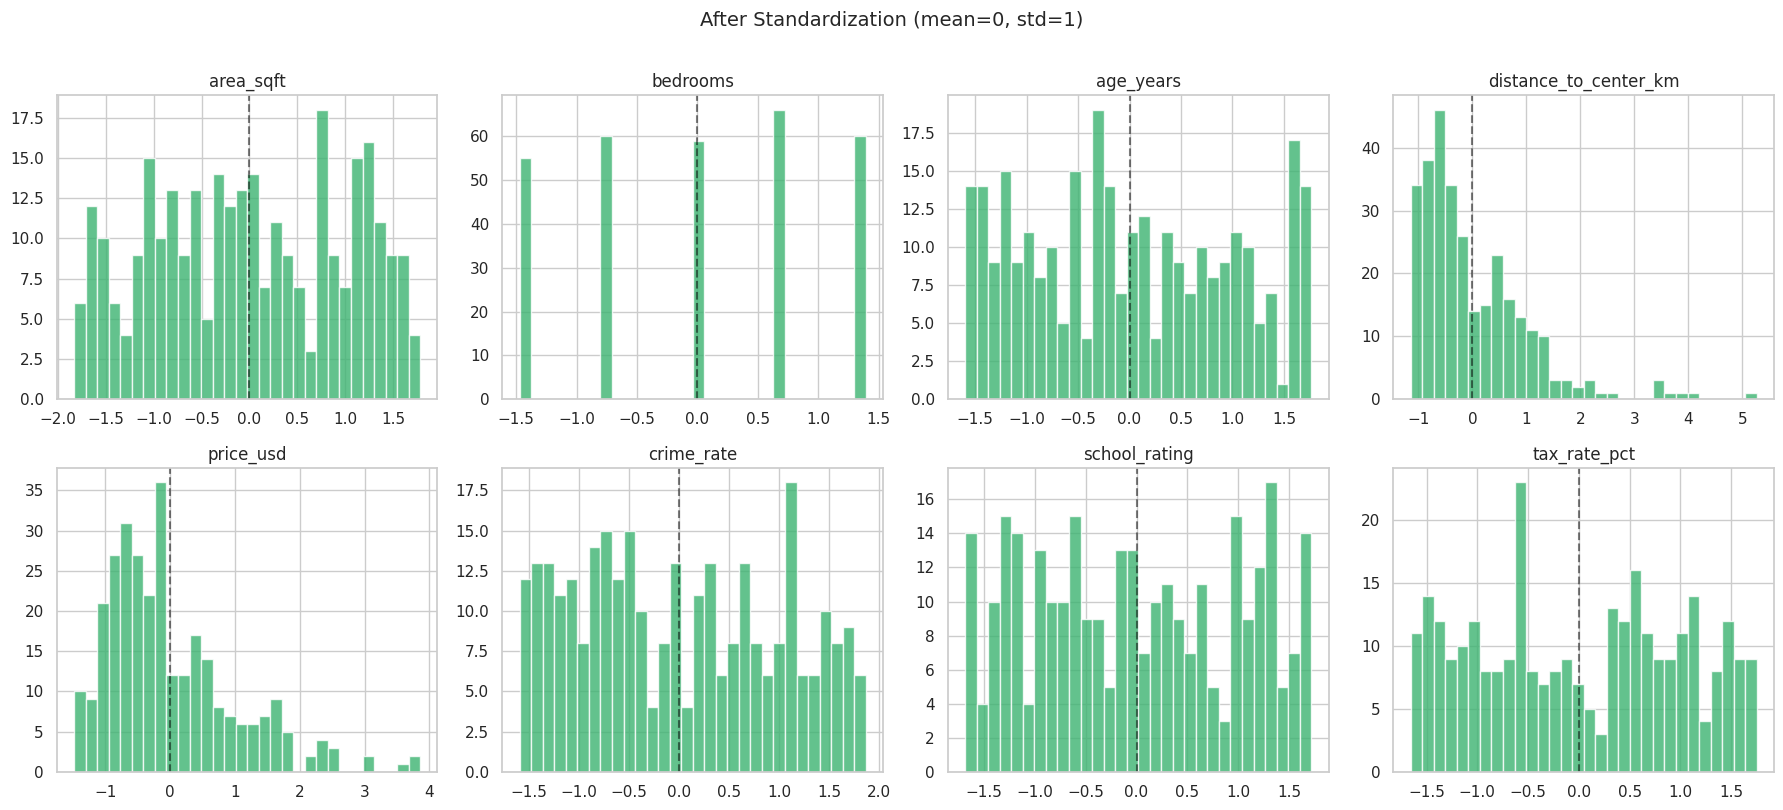

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, feature_cols):
    ax.hist(df_standard[col], bins=30, color="mediumseagreen", edgecolor="white", alpha=0.8)
    ax.set_title(f"{col}")
    ax.axvline(0, color="black", linestyle="--", alpha=0.5)

plt.suptitle("After Standardization (mean=0, std=1)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5 — Robust Scaling

Uses **median** and **IQR** instead of mean and std — resistant to outliers:

$$x_{\text{scaled}} = \frac{x - \text{median}}{\text{IQR}}$$

**When to use:** When your data has significant outliers.

In [9]:
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(
    scaler_robust.fit_transform(df[feature_cols]),
    columns=feature_cols
)

print("Robust Scaled — centered on median, scaled by IQR:")
df_robust.describe().round(3)

Robust Scaled — centered on median, scaled by IQR:


,area_sqft,bedrooms,age_years,distance_to_center_km,price_usd,crime_rate,school_rating,tax_rate_pct
count,300.000,300.000,300.000,300.000,300.000,300.000,300.000,300.000
mean,0.019,0.027,0.053,0.261,0.168,0.041,0.033,0.015
std,0.575,0.699,0.609,0.852,0.822,0.585,0.553,0.582
min,-1.030,-1.000,-0.917,-0.711,-1.044,-0.886,-0.896,-0.947
25%,-0.463,-0.500,-0.458,-0.326,-0.427,-0.451,-0.437,-0.492
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.537,0.500,0.542,0.674,0.573,0.549,0.563,0.508
max,1.041,1.000,1.125,4.736,3.333,1.130,0.979,1.033


## 6 — Log Transformation

For **right-skewed** data (like prices, distances), a log transform can make the distribution more symmetric:

$$x_{\text{log}} = \log(1 + x)$$

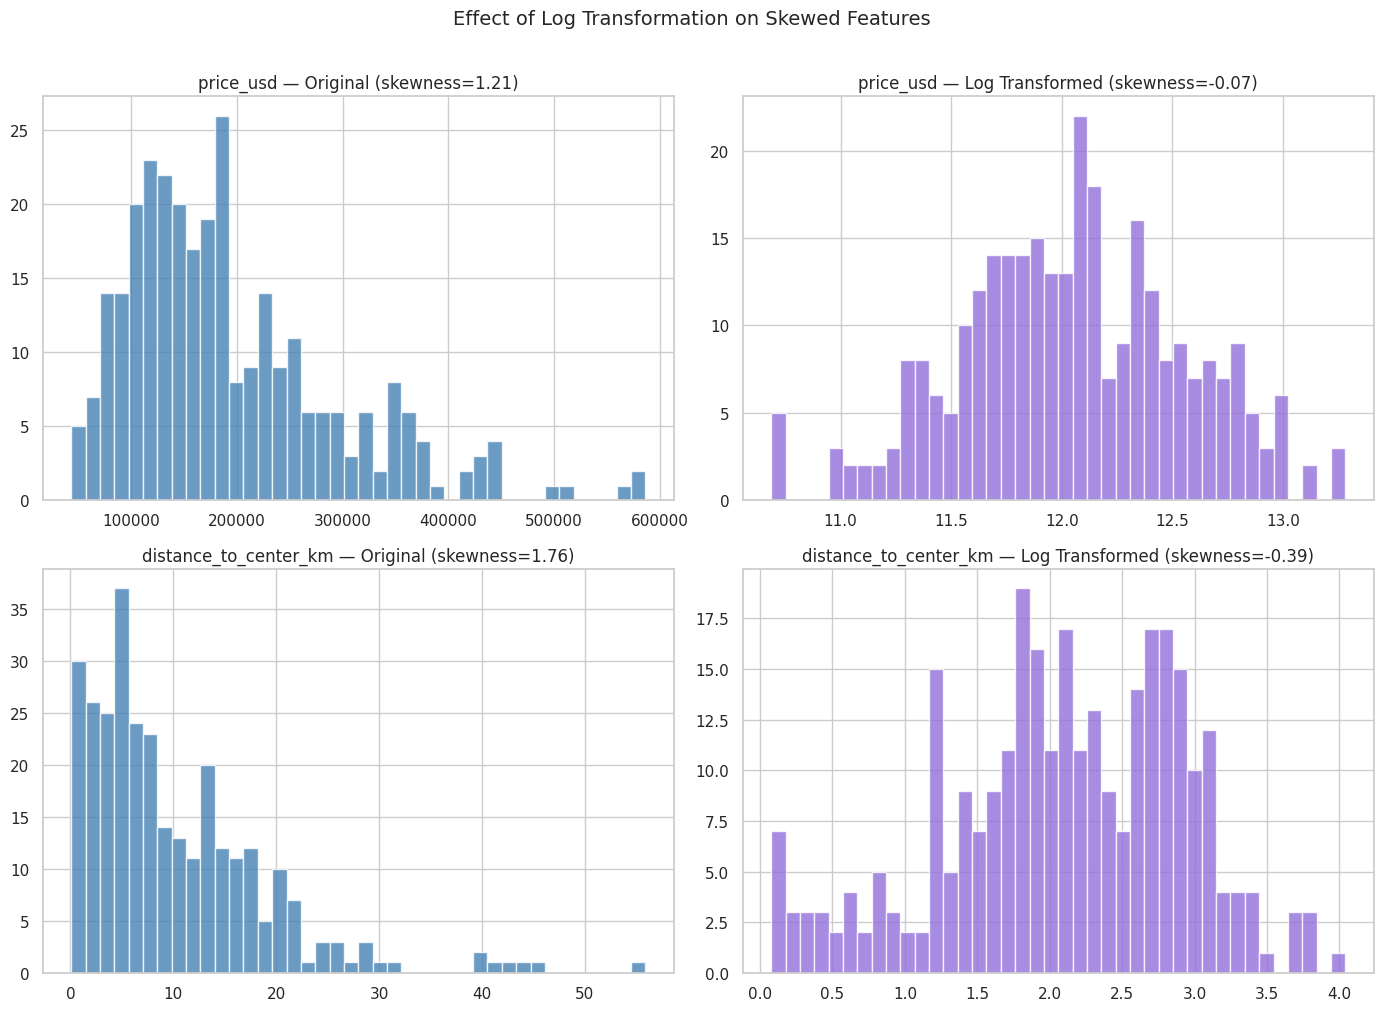

In [10]:
skewed_cols = ["price_usd", "distance_to_center_km"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(skewed_cols):
    # Original
    axes[i, 0].hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i, 0].set_title(f"{col} — Original (skewness={df[col].skew():.2f})")
    
    # Log-transformed
    log_vals = np.log1p(df[col])
    axes[i, 1].hist(log_vals, bins=40, color="mediumpurple", edgecolor="white", alpha=0.8)
    axes[i, 1].set_title(f"{col} — Log Transformed (skewness={log_vals.skew():.2f})")

plt.suptitle("Effect of Log Transformation on Skewed Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7 — Side-by-Side Comparison of All Methods

Let's pick one feature and compare all scaling methods on it.

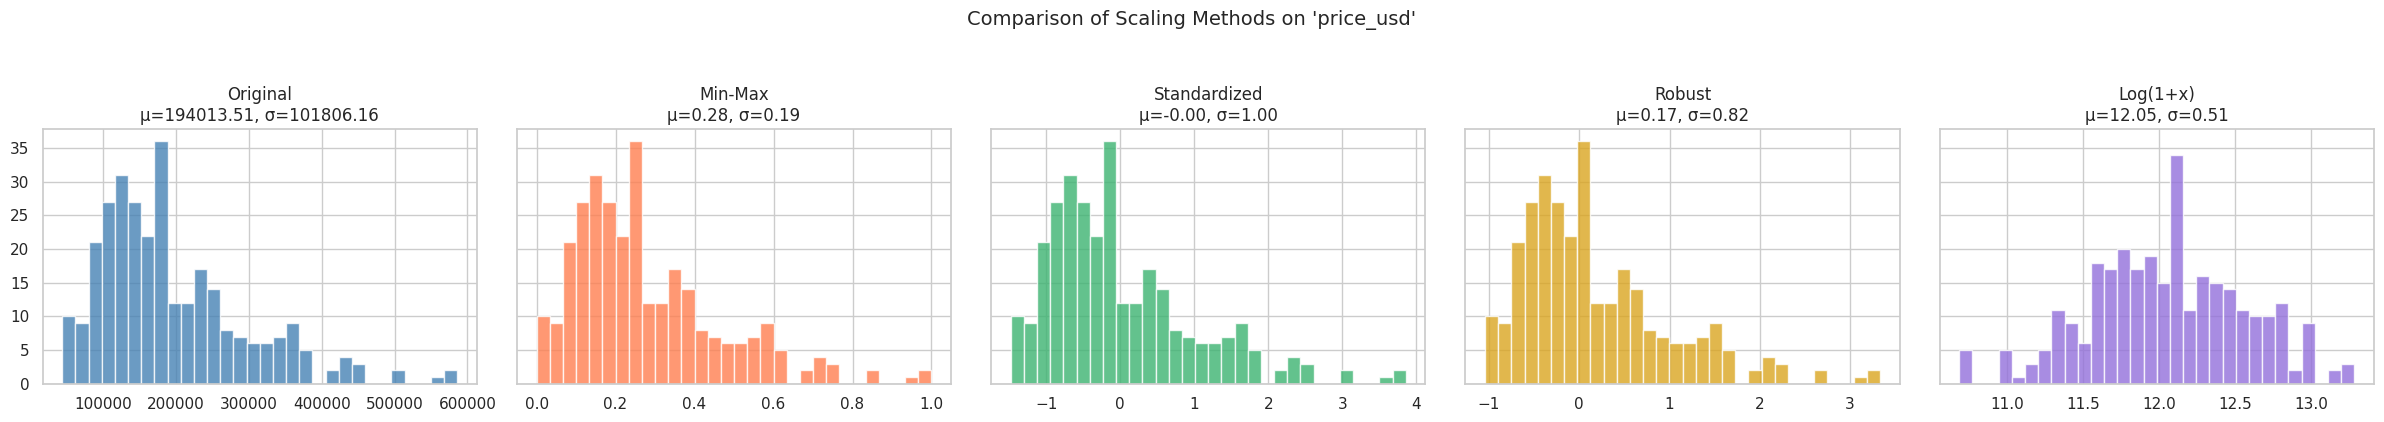

In [11]:
col = "price_usd"

fig, axes = plt.subplots(1, 5, figsize=(24, 4), sharey=True)
methods = [
    ("Original", df[col], "steelblue"),
    ("Min-Max", df_minmax[col], "coral"),
    ("Standardized", df_standard[col], "mediumseagreen"),
    ("Robust", df_robust[col], "goldenrod"),
    ("Log(1+x)", np.log1p(df[col]), "mediumpurple"),
]

for ax, (name, data, color) in zip(axes, methods):
    ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(f"{name}\nμ={data.mean():.2f}, σ={data.std():.2f}")

plt.suptitle(f"Comparison of Scaling Methods on '{col}'", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

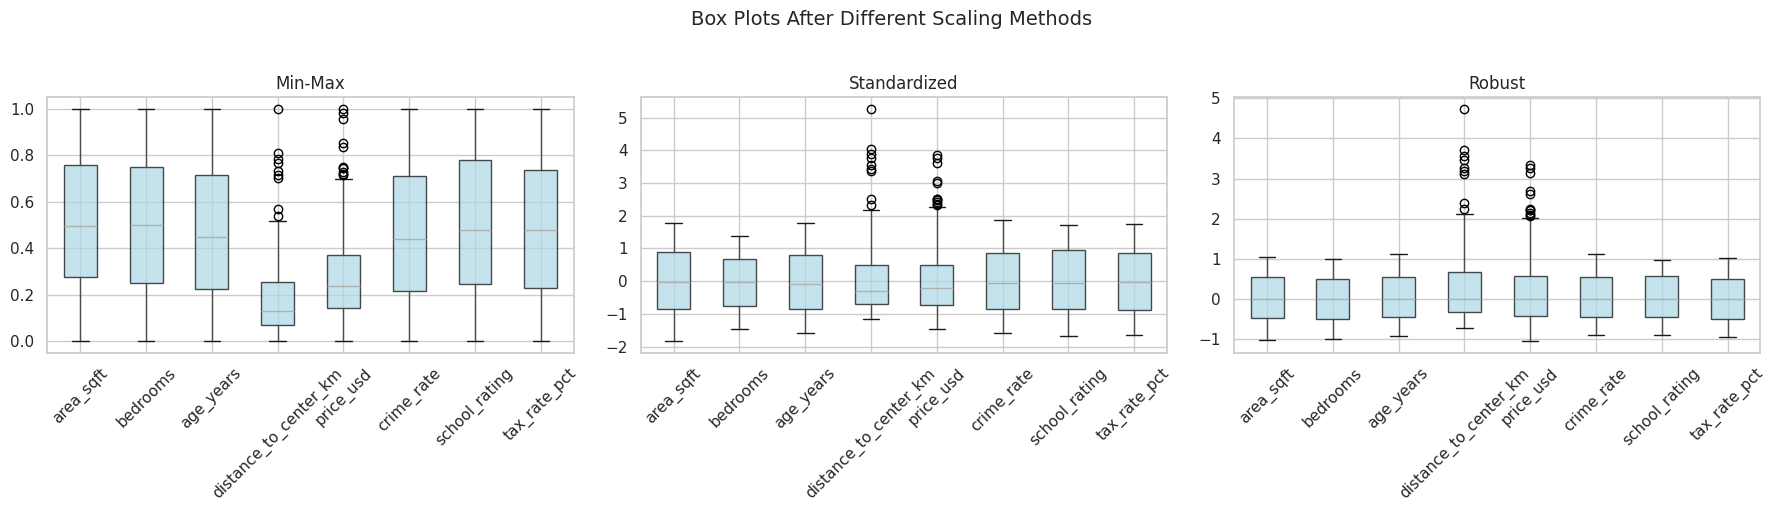

In [12]:
# Box-plot comparison across all features after each method
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, data) in zip(axes, [("Min-Max", df_minmax), ("Standardized", df_standard), ("Robust", df_robust)]):
    data.boxplot(ax=ax, vert=True, patch_artist=True,
                 boxprops=dict(facecolor="lightblue", alpha=0.7))
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Box Plots After Different Scaling Methods", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8 — Key Takeaways

| Method | Formula | Range | Best for |
|--------|---------|-------|----------|
| **Min-Max** | $(x - x_{\min}) / (x_{\max} - x_{\min})$ | [0, 1] | Bounded outputs, image data |
| **Standardization** | $(x - \mu) / \sigma$ | Unbounded | General purpose, PCA, linear models |
| **Robust** | $(x - \text{median}) / \text{IQR}$ | Unbounded | Data with outliers |
| **Log transform** | $\log(1 + x)$ | Unbounded | Right-skewed distributions |

### Tips
- **Always scale after train/test split** — fit on train, transform both
- Tree-based models (Random Forest, XGBoost) are **scale-invariant** — no need to scale
- Distance-based models (KNN, SVM, K-Means) **require** scaling
- Neural networks train faster with standardized inputs